## Mixed model for smooth decomposition 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl
import os, pickle, sys 
import seaborn as sb 
import pandas as pd
import statsmodels.formula.api as smf
from py_util_dx.py_utils import setProjectPath

%matplotlib inline 

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
projectPath, mainResultsPath = setProjectPath()
resultsPath = os.path.join(mainResultsPath, 'START_A2_smooth_decomposition')

In [4]:
datasets = ['MDTB', 'Nishimoto', 'HCPur100', 'Language', 'Demand', 'IBC']
smoothing_kernels = ['orig', 10, 8, 6, 4, 2, 'residuals']      # mm, fwhm
ROIs = ['PFC', 'parietal', 'visual', 'somatosensory']
colors = [(18/255, 75/255, 141/255), (0, 230/255, 230/255), (255/255, 165/255, 0/255), (240/255, 10/255, 240/255)]  # for ROIs 

In [5]:
vs_over_gs = {} 

for dataset_name in datasets:
    vs_over_gs[dataset_name] = {} 
    PKL_output = os.path.join(resultsPath, dataset_name, 'output_subject_wise.pkl') 

    with open(PKL_output, 'rb') as pf:
        output = pickle.load(pf) 

    for roi in ROIs:
        vs_over_gs[dataset_name][roi] = []         
        for kernel in smoothing_kernels:
            kernel = f'{kernel}_mm' 
            variance = output[kernel][roi] 
            vs_over_gs[dataset_name][roi].append(variance[:, 1]/variance[:, 0:2].sum(axis=1)) 
        vs_over_gs[dataset_name][roi] = np.array(vs_over_gs[dataset_name][roi]) 

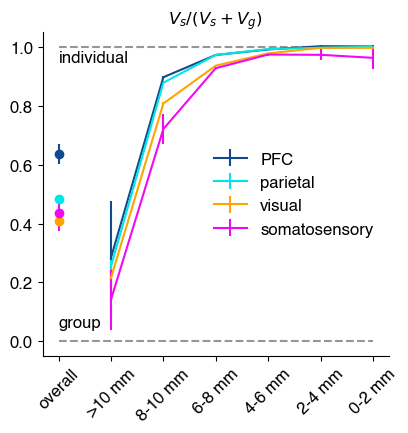

In [6]:
fig, ax = plt.subplots()
fig.set_figwidth(half_width) 
fig.set_figheight(4.5) 

for roiI, roi in enumerate(ROIs):
    data_agg = [] 
    for dataset_name in datasets:
        data_agg.append(vs_over_gs[dataset_name][roi])
    data_agg = np.hstack(data_agg) 
    
    data_agg_mean = data_agg.mean(axis=1)
    data_agg_ste = data_agg.std(axis=1) / np.sqrt(data_agg.shape[1]) 

    ax.errorbar(0, data_agg_mean[0], yerr=data_agg_ste[0], fmt='o', capsize=0, color=colors[roiI]) 
    ax.errorbar(x=np.arange(1, len(smoothing_kernels)), y=data_agg_mean[1:], yerr=data_agg_ste[1:], linestyle='-', color=colors[roiI], label=ROIs[roiI]) 

ax.hlines(0, xmin=0, xmax=len(smoothing_kernels)-1, linestyles='--', colors=(150/255, 150/255, 150/255))
ax.hlines(1, xmin=0, xmax=len(smoothing_kernels)-1, linestyles='--', colors=(150/255, 150/255, 150/255))
ax.text(0, 0.05, 'group')
ax.text(0, 0.95, 'individual')

xlabels = ['overall', '>10 mm', '8-10 mm', '6-8 mm', '4-6 mm', '2-4 mm', '0-2 mm']

ax.set_xticks(np.arange(len(smoothing_kernels)), xlabels, rotation=45)
ax.set_title('$V_s/(V_s+V_g)$', fontsize=12)

ax.legend(frameon=False, loc='right')
ax.set_ylim([-0.05, 1.05])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(resultsPath, f'vs_over_gs_subject_wise.jpg'), dpi=500, format='jpeg')

# with open(PKL_vis_output, 'wb') as pk:
#     pickle.dump(vis_output, pk)

plt.show()

In [7]:
# preparing the data for mixed model
data_mixed_model = {}
for kernelI, kernel in enumerate(smoothing_kernels):
    kernel = f'{kernel}_mm' 
    data_mixed_model[kernel] = {}
    data_mixed_model[kernel]['y'] = []
    data_mixed_model[kernel]['ROI'] = []
    data_mixed_model[kernel]['dataset'] = [] 
    for roiI, roi in enumerate(ROIs):
        for dataset_name in datasets:
            data_mixed_model[kernel]['y'].extend(list(vs_over_gs[dataset_name][roi][kernelI]))
            data_mixed_model[kernel]['ROI'].extend([roi] * len(vs_over_gs[dataset_name][roi][kernelI]))
            data_mixed_model[kernel]['dataset'].extend([dataset_name] * len(vs_over_gs[dataset_name][roi][kernelI]))

In [8]:
for kernelI, kernel in enumerate(smoothing_kernels):
    kernel = f'{kernel}_mm'
    print(kernel) 
    data = pd.DataFrame(data_mixed_model[kernel]) 
    model = smf.mixedlm('y ~ ROI', data, groups=data['dataset'], re_formula='~ ROI')
    result = model.fit()
    print(result.summary()) 

orig_mm


/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: 

                        Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           y        
No. Observations:           584               Method:                       REML     
No. Groups:                 6                 Scale:                        0.1758   
Min. group size:            24                Log-Likelihood:               -335.3888
Max. group size:            200               Converged:                    No       
Mean group size:            97.3                                                     
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                   0.694    0.065 10.743 0.000  0.567  0.820
ROI[T.parietal]                            -0.173    0.065 -2.676 0.007 -0.300

/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: 

                        Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           y        
No. Observations:           584               Method:                       REML     
No. Groups:                 6                 Scale:                        1.7504   
Min. group size:            24                Log-Likelihood:               -997.5187
Max. group size:            200               Converged:                    No       
Mean group size:            97.3                                                     
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                   0.340    0.151  2.261 0.024  0.045  0.635
ROI[T.parietal]                            -0.070    0.185 -0.377 0.706 -0.432

...

/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: 

                        Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           y       
No. Observations:            584               Method:                       REML    
No. Groups:                  6                 Scale:                        0.0133  
Min. group size:             24                Log-Likelihood:               416.4316
Max. group size:             200               Converged:                    No      
Mean group size:             97.3                                                    
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                   1.003    0.010 99.837 0.000  0.983  1.022
ROI[T.parietal]                            -0.005    0.015 -0.363 0.716 -0.034

/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: 

                        Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           y      
No. Observations:             584               Method:                       REML   
No. Groups:                   6                 Scale:                        0.0492 
Min. group size:              24                Log-Likelihood:               20.5560
Max. group size:              200               Converged:                    No     
Mean group size:              97.3                                                   
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                   0.995    0.067 14.945 0.000  0.864  1.125
ROI[T.parietal]                             0.006    0.063  0.093 0.926 -0.118

/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


## inference across datasets 

In [9]:
vs_over_gs = {} 

for dataset_name in datasets:
    vs_over_gs[dataset_name] = {} 
    PKL_output = os.path.join(resultsPath, dataset_name, 'output.pkl') 

    with open(PKL_output, 'rb') as pf:
        output = pickle.load(pf) 

    for roi in ROIs:
        vs_over_gs[dataset_name][roi] = []         
        for kernel in smoothing_kernels:
            kernel = f'{kernel}_mm' 
            variance = output[kernel][roi] 
            vs_over_gs[dataset_name][roi].append(variance[:, 1]/variance[:, 0:2].sum(axis=1)) 
        vs_over_gs[dataset_name][roi] = np.array(vs_over_gs[dataset_name][roi]).squeeze() 

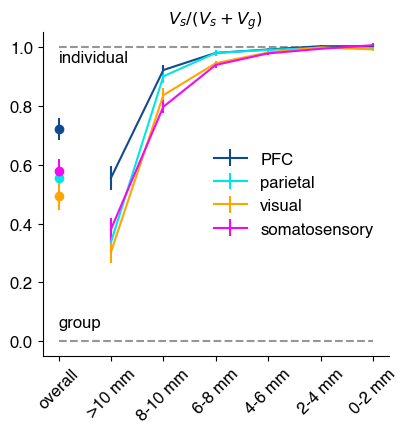

In [10]:
fig, ax = plt.subplots()
fig.set_figwidth(half_width) 
fig.set_figheight(4.5) 

for roiI, roi in enumerate(ROIs):
    data_agg = [] 
    for dataset_name in datasets:
        data_agg.append(vs_over_gs[dataset_name][roi])
    data_agg = np.array(data_agg)   # shape: (datasets x distances) 
    # print(data_agg.shape) 
    
    data_agg_mean = data_agg.mean(axis=0)
    data_agg_ste = data_agg.std(axis=0) / np.sqrt(data_agg.shape[0]) 

    ax.errorbar(0, data_agg_mean[0], yerr=data_agg_ste[0], fmt='o', capsize=0, color=colors[roiI]) 
    ax.errorbar(x=np.arange(1, len(smoothing_kernels)), y=data_agg_mean[1:], yerr=data_agg_ste[1:], linestyle='-', color=colors[roiI], label=ROIs[roiI]) 

ax.hlines(0, xmin=0, xmax=len(smoothing_kernels)-1, linestyles='--', colors=(150/255, 150/255, 150/255))
ax.hlines(1, xmin=0, xmax=len(smoothing_kernels)-1, linestyles='--', colors=(150/255, 150/255, 150/255))
ax.text(0, 0.05, 'group')
ax.text(0, 0.95, 'individual')

xlabels = ['overall', '>10 mm', '8-10 mm', '6-8 mm', '4-6 mm', '2-4 mm', '0-2 mm']

ax.set_xticks(np.arange(len(smoothing_kernels)), xlabels, rotation=45)
ax.set_title('$V_s/(V_s+V_g)$', fontsize=12)

ax.legend(frameon=False, loc='right')
ax.set_ylim([-0.05, 1.05])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(resultsPath, f'vs_over_gs_global.jpg'), dpi=500, format='jpeg')

# with open(PKL_vis_output, 'wb') as pk:
#     pickle.dump(vis_output, pk)

plt.show()